In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [2]:
df_DA_US = df[(df['job_title_short']=='Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

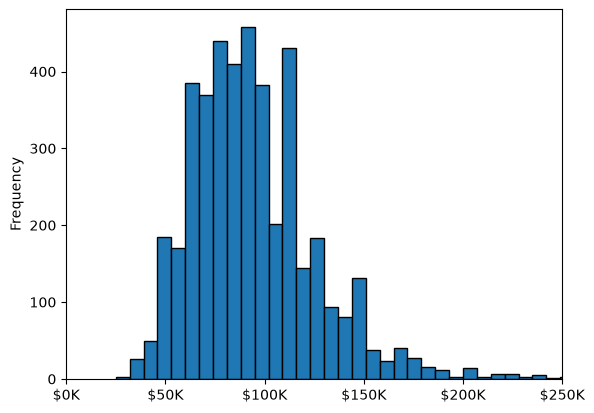

In [3]:
df_DA_US['salary_year_avg'].plot(kind='hist' , bins=50 , edgecolor='black')
plt.xlim(0,250000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'${int(y/1000)}K'))
# add title and x & y labels to clear the plot


In [4]:
df_DA_US['salary_year_avg'].sample(10)

402095     89796.0
4726       80000.0
201918    112434.0
540784    150000.0
472381     62500.0
757309     70000.0
455948     89978.5
320901     93000.0
320553     55000.0
742680     81500.0
Name: salary_year_avg, dtype: float64

<Axes: >

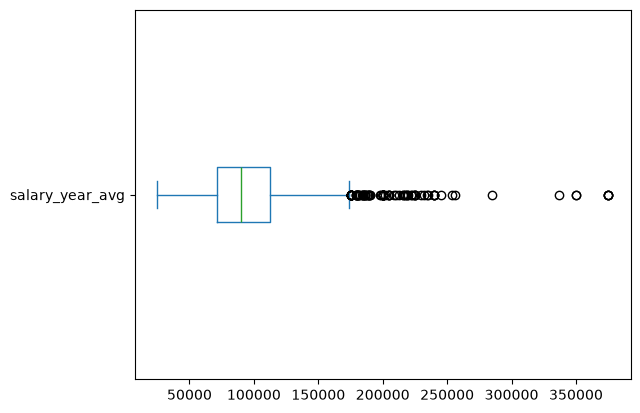

In [5]:
df_DA_US['salary_year_avg'].plot(kind='box' ,vert=False)

C:\Users\Kacha\AppData\Local\Temp\ipykernel_7400\4135665105.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list , tick_labels= job_titles , vert=False)


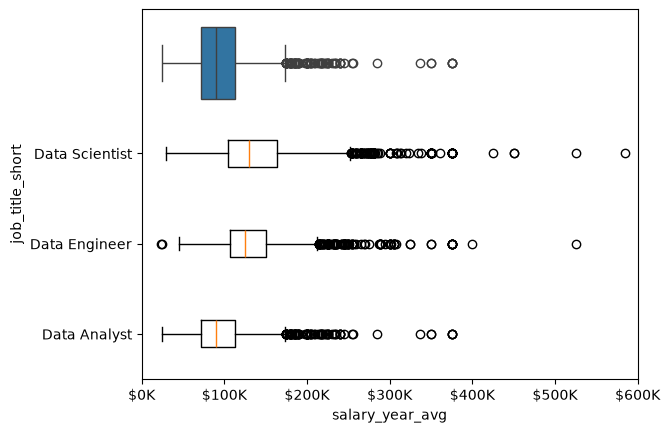

In [10]:
import seaborn as sns
job_titles = ['Data Scientist','Data Engineer','Data Analyst']
df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()

df_US = df_US.dropna(subset=['salary_year_avg'])

sns.boxplot(data=df_DA_US , x='salary_year_avg' , y='job_title_short')

job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list , tick_labels= job_titles , vert=False)
plt.xlim(0,600000)
ax = plt.gca()

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
plt.show()

In [7]:
df_US['job_title_short'].value_counts()

job_title_short
Data Scientist    4553
Data Analyst      4350
Data Engineer     2915
Name: count, dtype: int64

In [8]:
job_list[0]

100       228222.0
116       114000.0
257       103128.0
450       157500.0
1257       70700.0
            ...   
785324    234500.0
785488    115000.0
785563    136400.0
785648    221875.0
785692    157500.0
Name: salary_year_avg, Length: 4553, dtype: float64